In [11]:
import pandas as pd
from textblob import TextBlob
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("ecommerce_reviews.csv")

In [12]:
def get_sentiment(review):
    polarity = TextBlob(review).sentiment.polarity
    if polarity > 0:
        return "Positive"
    elif polarity < 0:
        return "Negative"
    else:
        return "Neutral"

In [13]:

df["Sentiment"] = df["Review_Text"].apply(get_sentiment)
df.head()   

,Review_ID,Product_Name,Category,Brand,Price,Rating,Review_Text,Review_Date,Verified_Purchase,Helpful_Votes,Review_Length,Discount_Percentage,Sentiment
0,1,PS5,Gaming,Samsung,37206.75,3,It's decent. Nothing special but works fine. C...,2023-04-15,True,456,106,50,Positive
1,2,Refrigerator,Electronics,Lenovo,2073.24,2,Broken on arrival. Very upset. But course act ...,2024-06-01,True,287,79,15,Negative
2,3,Gaming Headset,Gaming,Lenovo,11411.81,4,Amazing product! Exceeded my expectations. Hig...,2023-06-13,True,174,154,20,Positive
3,4,iPhone 13,Smartphones,HP,5559.41,4,Superb product. Great customer service too. Va...,2023-12-19,True,413,124,0,Positive
4,5,Mechanical Keyboard,Gaming,OnePlus,6678.90,5,Great quality and fast delivery. Very satisfie...,2023-10-28,True,316,96,25,Positive


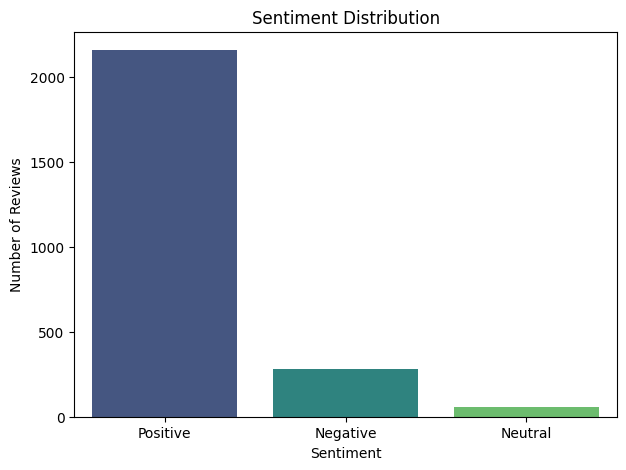

In [14]:
sentiment = df["Sentiment"].value_counts()

plt.figure(figsize=(7,5))

sns.barplot(
    x=sentiment.index,
    y=sentiment.values,
    hue=sentiment.index,
    palette="viridis",
    legend=False
)

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

plt.show()

In [15]:
(df["Sentiment"].value_counts(normalize=True)*100).round(2)

Sentiment
Positive    86.44
Negative    11.36
Neutral      2.20
Name: proportion, dtype: float64

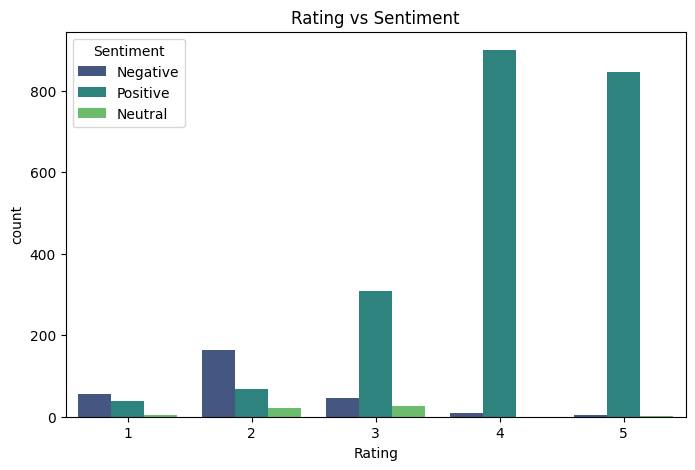

In [16]:
plt.figure(figsize=(8,5))

sns.countplot(x="Rating",hue="Sentiment",data=df,palette="viridis")
plt.title("Rating vs Sentiment")
plt.show()

In [17]:
df[df["Sentiment"]=="Positive"][
    ["Product_Name","Review_Text"]
].head()

,Product_Name,Review_Text
0,PS5,It's decent. Nothing special but works fine. C...
2,Gaming Headset,Amazing product! Exceeded my expectations. Hig...
3,iPhone 13,Superb product. Great customer service too. Va...
4,Mechanical Keyboard,Great quality and fast delivery. Very satisfie...
6,XPS 13,Outstanding quality! Will definitely buy again...


In [18]:
df[df["Sentiment"]=="Negative"][
    ["Product_Name","Review_Text"]
].head()

,Product_Name,Review_Text
1,Refrigerator,Broken on arrival. Very upset. But course act ...
5,Phone Case,Satisfactory. Met my expectations. Type treat ...
10,MacBook Pro,Disappointing. Not as described. Later our bor...
22,iPhone 13,Terrible experience. Do not recommend. Throw m...
28,Refrigerator,Poor quality. Waste of money. Loss energy only...
